<h1>Final Project</h1>
<hr>
<h2>Family and House Expenditure Data Analytics</h2>
<h5>This Analytics is consisting of Descriptive,Diagnostics and Predictive analytics</h5>
<hr>

<h5>Analyst: Mark John Well D. De Castro</h5>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
import sklearn
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression

<h2>Converting Datasets to DataFrames</h2>

In [2]:
data = pd.read_csv("Family Income and Expenditure.csv")

In [3]:
data

,Total Household Income,Region,Total Food Expenditure,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle
0,480332,CAR,117848,Wage/Salaries,0,42140,38300,24676,16806,3325,...,1,1,0,0,0,2,1,0,0,1
1,198235,CAR,67766,Wage/Salaries,0,17329,13008,17434,11073,2035,...,0,1,0,0,0,3,1,0,0,2
2,82785,CAR,61609,Wage/Salaries,1,34182,32001,7783,2590,1730,...,0,0,0,0,0,0,0,0,0,0
3,107589,CAR,78189,Wage/Salaries,0,34030,28659,10914,10812,690,...,0,0,0,0,0,1,0,0,0,0
4,189322,CAR,94625,Wage/Salaries,0,34820,30167,18391,11309,1395,...,1,0,0,0,0,3,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41539,119773,XII - SOCCSKSARGEN,44875,Enterpreneurial Activities,1,23675,21542,1476,6120,1632,...,0,0,0,0,0,1,0,0,0,0
41540,137320,XII - SOCCSKSARGEN,31157,Enterpreneurial Activities,1,2691,1273,1886,4386,1840,...,0,0,0,0,0,3,0,0,0,0
41541,133171,XII - SOCCSKSARGEN,45882,Enterpreneurial Activities,2,28646,27339,480,4796,1232,...,0,0,0,0,0,1,0,0,0,0
41542,129500,XII - SOCCSKSARGEN,81416,Enterpreneurial Activities,1,29996,26655,2359,17730,2923,...,0,0,0,0,0,2,0,0,0,0


<h2>Checking and Filling Up Null Values</h2>

In [4]:
data['Household Head Occupation'].mode()
data['Household Head Occupation'] = data['Household Head Occupation'].fillna(data['Household Head Occupation'].mode()[0])

data['Household Head Class of Worker'].mode()
data['Household Head Class of Worker'] = data['Household Head Class of Worker'].fillna(data['Household Head Class of Worker'].mode()[0])

data['Toilet Facilities'].mode()
data['Toilet Facilities'] = data['Toilet Facilities'].fillna(data['Toilet Facilities'].mode()[0])

In [5]:
data.isnull().sum()

Total Household Income                           0
Region                                           0
Total Food Expenditure                           0
Main Source of Income                            0
Agricultural Household indicator                 0
Bread and Cereals Expenditure                    0
Total Rice Expenditure                           0
Meat Expenditure                                 0
Total Fish and  marine products Expenditure      0
Fruit Expenditure                                0
Vegetables Expenditure                           0
Restaurant and hotels Expenditure                0
Alcoholic Beverages Expenditure                  0
Tobacco Expenditure                              0
Clothing, Footwear and Other Wear Expenditure    0
Housing and water Expenditure                    0
Imputed House Rental Value                       0
Medical Care Expenditure                         0
Transportation Expenditure                       0
Communication Expenditure      

<h3>NOTE: This Data analytics will fucos on NCR, CALABARZON, BARMM and their expenditures</h1>

<h1>DESCRIPTIVE ANALYTICS</h1>
<hr>

<h1>The Income Distribution of the NCR, ARMM, IVA - CALABRZON</h1>

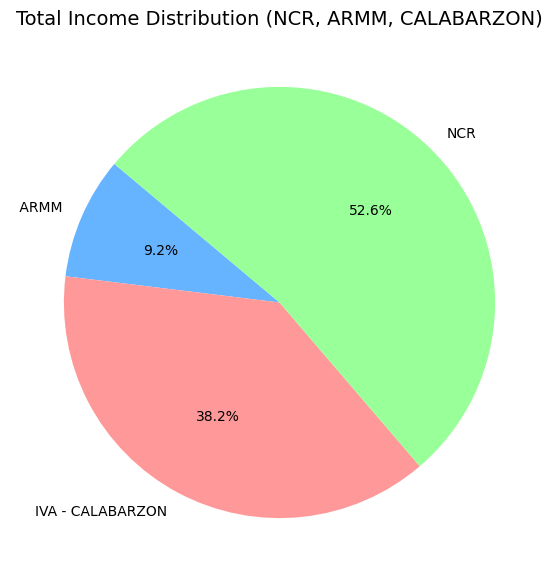

In [6]:
# Filter rows using partial string match for region names
filtered_data = data[data["Region"].str.contains("NCR|ARMM|IVA - CALABARZON", case=False, na=False)]

# Group by Region and sum the Total_Income
income_summary = filtered_data.groupby("Region")["Total Household Income"].sum()

# Plot pie chart
plt.figure(figsize=(7,7))
plt.pie(income_summary, 
        labels=income_summary.index, 
        autopct="%1.1f%%", 
        startangle=140, 
        colors=["#66b3ff", "#ff9999", "#99ff99"])

plt.title("Total Income Distribution (NCR, ARMM, CALABARZON)", fontsize=14)
plt.show()

<h1>INSIGHT 1:</h1>
<h4>CALABARZON’s higher total income reflects its strong agro-industrial base, with thriving livestock, poultry, and crop production supported by proximity to Metro Manila markets. ARMM’s lower income share highlights structural challenges in agricultural productivity, such as limited infrastructure, fragmented supply chains, and reliance on subsistence farming despite rich natural resources. Meanwhile, NCR’s income dominance is not rooted in farming but in urban services and trade; however, its demand for agricultural products drives market opportunities for surrounding regions. This comparison underscores how agricultural strength directly boosts CALABARZON’s income, while ARMM’s potential remains underutilized, and NCR’s role is more as a consumer hub than a producer.</h4>

<h1>INSIGHTS 2:</h1>

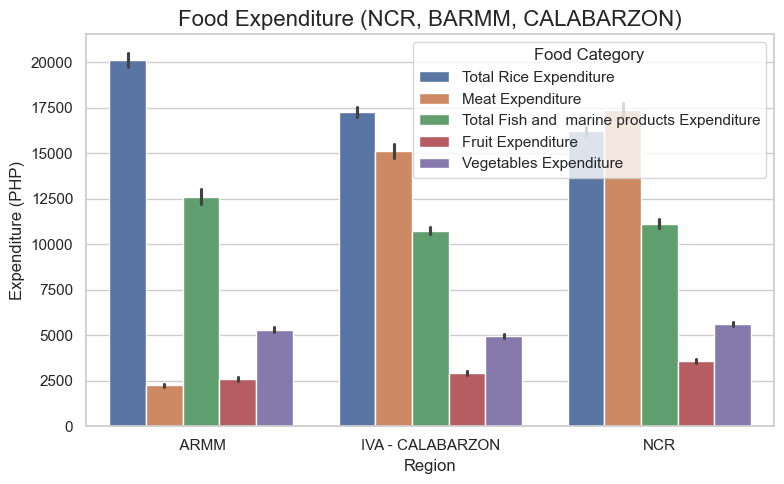

In [7]:
# Filter only NCR, BARMM, and CALABARZON
regions_of_interest = ["NCR", " ARMM", "IVA - CALABARZON"]
filtered_data = data[data["Region"].isin(regions_of_interest)]

# Select relevant columns
food_cols = ["Region", "Total Rice Expenditure", "Meat Expenditure", "Total Fish and  marine products Expenditure", "Fruit Expenditure", "Vegetables Expenditure"]
food_df = filtered_data[food_cols]

# Melt the dataframe for grouped plotting
food_melted = food_df.melt(id_vars="Region", 
                           var_name="Food_Category", 
                           value_name="Expenditure")

# Set plot style
sns.set(style="whitegrid")

# Grouped bar chart
plt.figure(figsize=(8,5))
sns.barplot(data=food_melted, 
            x="Region", 
            y="Expenditure", 
            hue="Food_Category")

plt.title("Food Expenditure (NCR, BARMM, CALABARZON)", fontsize=16)
plt.ylabel("Expenditure (PHP)")
plt.xlabel("Region")
plt.legend(title="Food Category")
plt.tight_layout()
plt.show()

<h2>INSIGHT 2:</h2>
<h4>The chart reveals distinct regional spending patterns on food in the Philippines, highlighting that ARMM allocates the highest expenditure on rice, CALABARZON leads in meat spending, and NCR maintains relatively balanced expenditures across all categories. These differences reflect regional dietary preferences, economic capacity, and access to food sources—ARMM’s rice-heavy spending suggests staple reliance, CALABARZON’s meat dominance aligns with higher income and urbanization, while NCR’s even distribution indicates diversified consumption and market access.</h4>

<h1>INSIGHT 3:</h1>

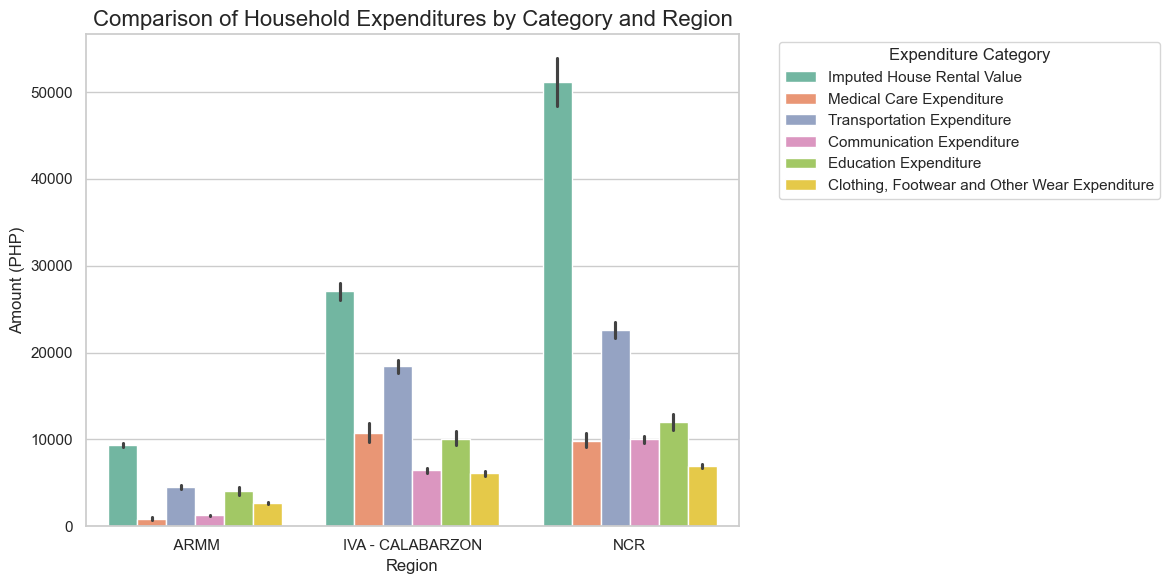

In [8]:
# Filter rows for NCR, ARMM, and CALABARZON using partial match
target_regions = ["NCR", "ARMM", "CALABARZON"]
filtered_data = data[data["Region"].str.contains("NCR|ARMM|CALABARZON", case=False, na=False)]

# Select relevant expenditure columns
selected_cols = [
    "Region",
    "Imputed House Rental Value",
    "Medical Care Expenditure",
    "Transportation Expenditure",
    "Communication Expenditure",
    "Education Expenditure",
    "Clothing, Footwear and Other Wear Expenditure"
]
subset = filtered_data[selected_cols]

# Melt the DataFrame for grouped plotting
melted = subset.melt(id_vars="Region", 
                     var_name="Expenditure Category", 
                     value_name="Amount")

# Plot grouped bar chart
plt.figure(figsize=(12,6))
sns.barplot(data=melted, 
            x="Region", 
            y="Amount", 
            hue="Expenditure Category", 
            palette="Set2")

plt.title("Comparison of Household Expenditures by Category and Region", fontsize=16)
plt.ylabel("Amount (PHP)")
plt.xlabel("Region")
plt.legend(title="Expenditure Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<h1>INSIGHt 3:</h1>
<h4>The chart reveals significant regional disparities in household spending, with NCR and CALABARZON showing notably higher expenditures in imputed rent, transportation, education, and medical care compared to ARMM. These patterns reflect the urbanized nature of NCR and the semi-urban, agro-industrial profile of CALABARZON, where access to services and infrastructure drives up costs. In contrast, ARMM’s lower spending across all categories suggests limited access to essential services and lower household purchasing power. From an agricultural perspective, these differences imply that regions with better infrastructure and higher education investment—like CALABARZON—may foster more resilient and productive farming communities, while ARMM’s constraints highlight the need for targeted support to improve rural livelihoods and service access.</h4>

<h1>INSIGHT4:</h1>

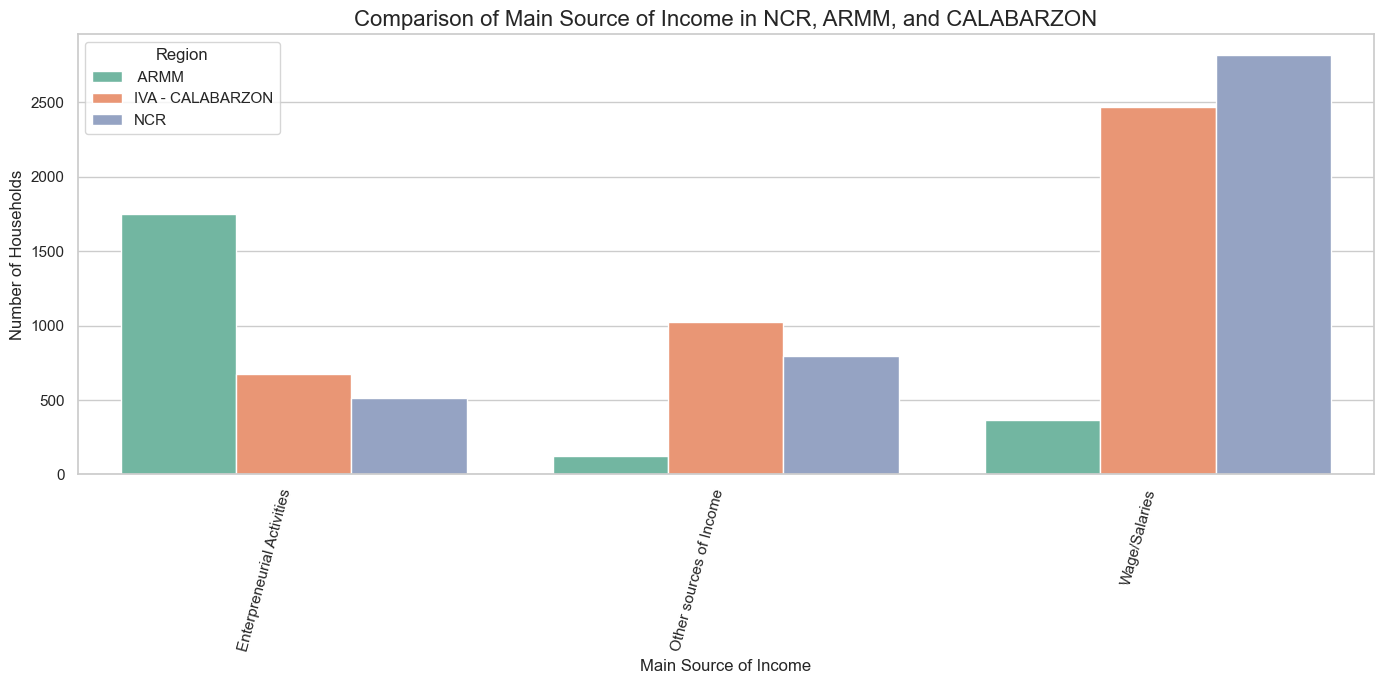

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter rows for NCR, ARMM, and CALABARZON using partial match
target_regions = ["NCR", " ARMM", " IVA - CALABARZON"]
filtered_data = data[data["Region"].str.contains("NCR| ARMM|IVA - CALABARZON", case=False, na=False)]

# Count households by main source of income per region
income_counts = (
    filtered_data.groupby(["Region", "Main Source of Income"])
    .size()
    .reset_index(name="Count")
)

# Plot grouped bar chart
plt.figure(figsize=(14,7))
sns.barplot(data=income_counts, 
            x="Main Source of Income", 
            y="Count", 
            hue="Region", 
            palette="Set2")

plt.title("Comparison of Main Source of Income in NCR, ARMM, and CALABARZON", fontsize=16)
plt.xticks(rotation=75, ha="right")
plt.ylabel("Number of Households")
plt.xlabel("Main Source of Income")
plt.legend(title="Region")
plt.tight_layout()
plt.show()


<h1>INSIGHT 4:</h1>
<h4>main sources of income across NCR, ARMM, and CALABARZON reveals distinct regional economic profiles. In NCR and CALABARZON, the majority of households rely on wages and salaries, reflecting their urban and semi-urban labor markets dominated by formal employment. In contrast, ARMM shows a strong dependence on entrepreneurial activities, indicating a more informal, self-reliant economy where households often engage in small-scale farming, trading, or local services. This divergence highlights how urbanization and infrastructure access shape income strategies, with wage employment thriving in developed regions, while entrepreneurship remains vital in rural areas with limited formal job opportunities. Understanding these patterns is crucial for tailoring agricultural and livelihood programs to each region’s economic realities.</h4>

<h1>DIAGNOSTIC ANALYTICS</h1>

<H1>INSIGHT 5:</H1>

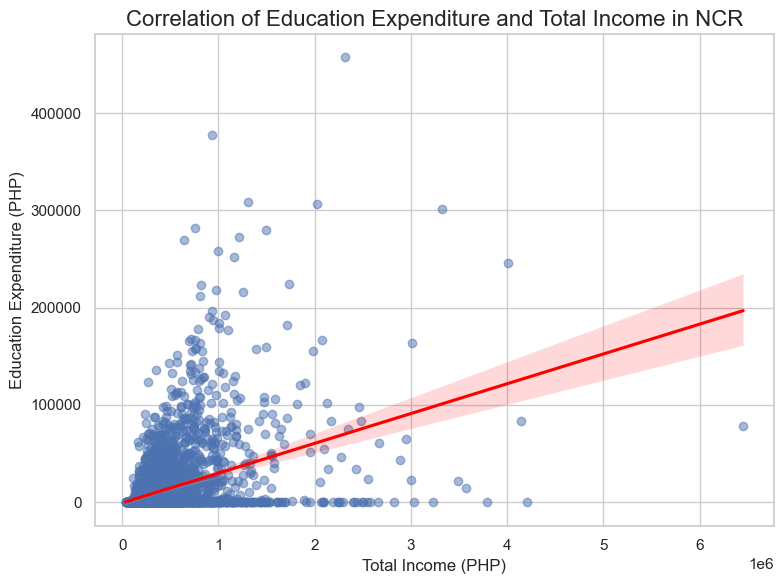

In [10]:
# Filter rows for NCR
ncr_data = data[data["Region"].str.contains("NCR", case=False, na=False)]

# Scatter plot with regression line
plt.figure(figsize=(8,6))
sns.regplot(data=ncr_data, 
            x="Total Household Income", 
            y="Education Expenditure", 
            scatter_kws={"alpha":0.5}, 
            line_kws={"color":"red"})

plt.title("Correlation of Education Expenditure and Total Income in NCR", fontsize=16)
plt.xlabel("Total Income (PHP)")
plt.ylabel("Education Expenditure (PHP)")
plt.tight_layout()
plt.show()

<h1>INSIGHT 5:</h1>
<h4>The scatter plot reveals a clear positive correlation between total income and education expenditure among households in NCR, indicating that as income increases, families tend to allocate more resources toward education. This trend reflects the urban prioritization of academic advancement, where higher-income households invest in better schooling, private education, or supplemental learning. It also suggests that education spending in NCR is income-sensitive, meaning lower-income families may face barriers to accessing quality education. From a policy perspective, this underscores the need for targeted educational subsidies or public investment to ensure equitable access, especially in densely populated urban regions where education is a key driver of upward mobility.</h4>

<h1>INSIGHT 6:</h1>

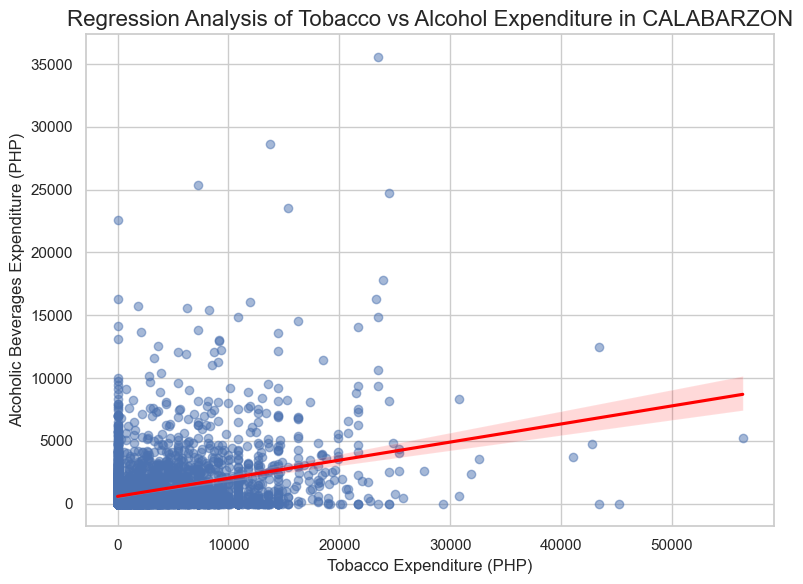

Correlation coefficient: 0.3312736345307056


In [11]:
# Filter rows for CALABARZON
calabarzon_data = data[data["Region"].str.contains("CALABARZON", case=False, na=False)]

# Scatter plot with regression line
plt.figure(figsize=(8,6))
sns.regplot(data=calabarzon_data,
            x="Tobacco Expenditure",
            y="Alcoholic Beverages Expenditure",
            scatter_kws={"alpha":0.5},
            line_kws={"color":"red"})

plt.title("Regression Analysis of Tobacco vs Alcohol Expenditure in CALABARZON", fontsize=16)
plt.xlabel("Tobacco Expenditure (PHP)")
plt.ylabel("Alcoholic Beverages Expenditure (PHP)")
plt.tight_layout()
plt.show()

# Calculate correlation coefficient
corr_value = calabarzon_data["Tobacco Expenditure"].corr(calabarzon_data["Alcoholic Beverages Expenditure"])
print("Correlation coefficient:", corr_value)

<h1>INSIGHT 6:</h1>
<h4>The regression analysis for CALABARZON households reveals a positive correlation between tobacco and alcoholic beverages expenditures, indicating that families who spend more on one tend to spend more on the other. This suggests a shared behavioral or cultural pattern in discretionary spending, where these two categories often co-occur.</h4>

<h1>INSIGHT 7:</h1>

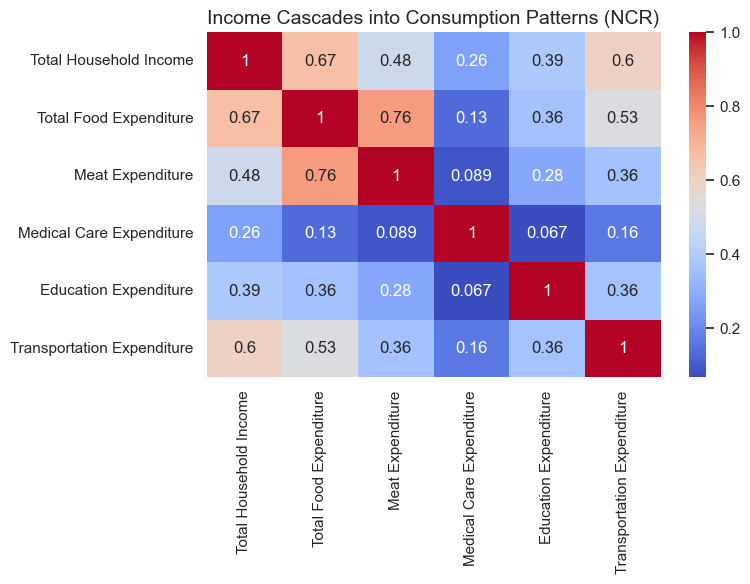

In [16]:
# Filter for NCR only
ncr_data = data[data["Region"].str.contains("NCR", case=False, na=False)]

# Select relevant columns
cols = ['Total Household Income', 'Total Food Expenditure', 'Meat Expenditure', 
        'Medical Care Expenditure', 'Education Expenditure', 'Transportation Expenditure']

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ncr_data[cols].corr(), annot=True, cmap='coolwarm')

plt.title("Income Cascades into Consumption Patterns (NCR)", fontsize=14)
plt.tight_layout()
plt.show()

<h1>INSIGHT 7:</h1>
<h4>The heatmap reveals that in NCR, total household income is strongly correlated with food (0.67), transportation (0.60), and meat expenditure (0.48), suggesting that as income rises, households prioritize mobility and dietary quality. Moderate correlations with education (0.39) and medical care (0.26) indicate that while these are important, they may be constrained by affordability or access. The weak link between income and medical spending implies that healthcare costs may not scale proportionally with income, possibly due to reliance on public services or deferred care. Overall, the pattern shows that income cascades into consumption, with food and transport acting as primary channels, while education and health remain secondary yet essential investments.</h4>

<h1>INSIGHT 8:</h1>

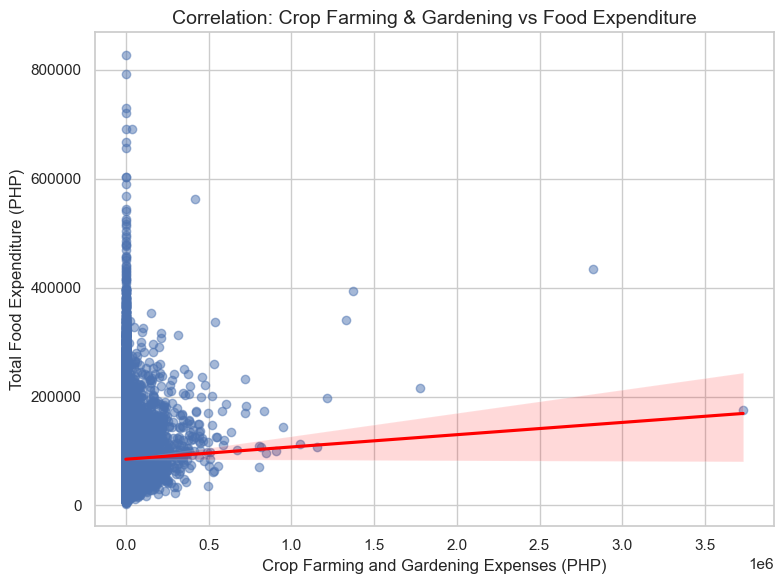

Correlation coefficient: 0.02079971470787697


In [13]:
# Scatter plot with regression line
plt.figure(figsize=(8,6))
sns.regplot(data=data,
            x="Crop Farming and Gardening expenses",
            y="Total Food Expenditure",
            scatter_kws={"alpha":0.5},
            line_kws={"color":"red"})

plt.title("Correlation: Crop Farming & Gardening vs Food Expenditure", fontsize=14)
plt.xlabel("Crop Farming and Gardening Expenses (PHP)")
plt.ylabel("Total Food Expenditure (PHP)")
plt.tight_layout()
plt.show()

# Calculate correlation coefficient
corr_value = data["Crop Farming and Gardening expenses"].corr(data["Total Food Expenditure"])
print("Correlation coefficient:", corr_value)

<h1>INSIGHT 8:</h1>
<h4>The correlation analysis between Crop Farming and Gardening Expenses and Total Food Expenditure reveals a very weak positive relationship (correlation coefficient ≈ 0.02), suggesting that households investing more in farming and gardening do not significantly reduce their food spending. This challenges the assumption that homegrown food offsets market purchases. Instead, it may indicate that crop-related expenses are driven by non-subsistence motives—such as commercial production, cultural practices, or seasonal variability—rather than direct food substitution. For agricultural diagnostics, this implies that farming inputs alone are not reliable predictors of household food security, and that broader factors like access to markets, crop diversity, and household size may play a more decisive role.</h4>

<h1>PREDICTIVE ANALYTICS</h1>

<h1>INSIGHT 9:</h1>

RMSE: 33298.05
R² Score: 0.67


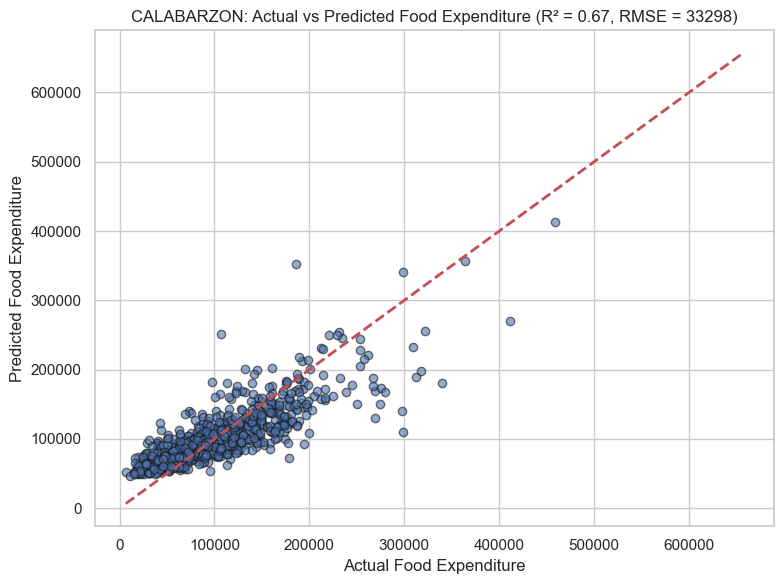

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Filter for CALABARZON only
calabarzon_data = data[data["Region"].str.contains("CALABARZON", case=False, na=False)]

# Features and target
features = [
    'Transportation Expenditure',
    'Education Expenditure',
    'Medical Care Expenditure',
    'Total Income from Entrepreneurial Acitivites',
    'Total number of family members employed',
    'Household Head Age',
    'Total Household Income'
]
target = 'Total Food Expenditure'

# Prepare data
df_model = calabarzon_data[features + [target]].dropna()
X = df_model[features]
y = df_model[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual Food Expenditure")
plt.ylabel("Predicted Food Expenditure")
plt.title(f"CALABARZON: Actual vs Predicted Food Expenditure (R² = {r2:.2f}, RMSE = {rmse:.0f})")
plt.tight_layout()
plt.show()

<h1>INSIGHT 9:</h1>
<h4>The predictive model for Total Food Expenditure in CALABARZON shows a stronger fit than previous regional models, with an R² score of 0.67 and an RMSE of ₱33,298. This indicates that household-level variables—such as income, education, transportation, and entrepreneurial activity—can explain two-thirds of the variation in food spending within the region. The relatively low RMSE suggests that predictions are reasonably close to actual values, especially for middle-income households.</h4>

<h1>INSIGHT 10:</h1>

RMSE: 0.1126
R² Score: 0.4149


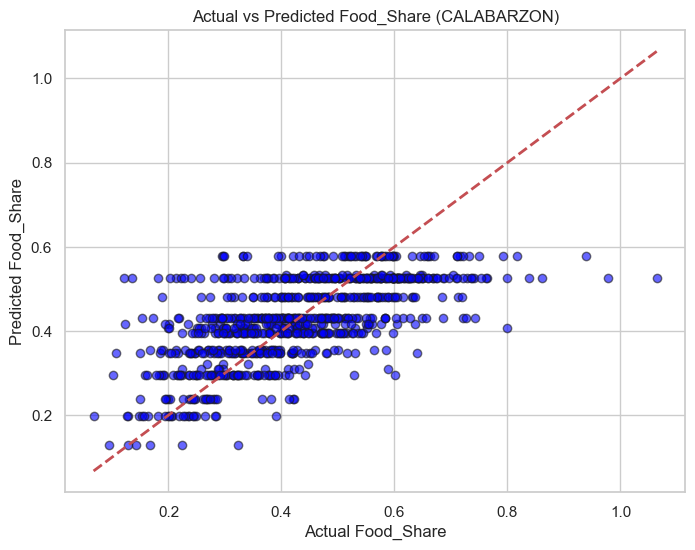

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

calabarzon_data = data[data["Region"].str.contains("CALABARZON", case=False, na=False)]

calabarzon_data["Food_Share"] = (
    calabarzon_data["Total Food Expenditure"] / calabarzon_data["Total Household Income"]
)

features = [
    "Total Household Income",
    "Transportation Expenditure",
    "Medical Care Expenditure",
    "Total number of family members employed",
    "Household Head Age",
    "Crop Farming and Gardening expenses"
]

X = calabarzon_data[features]
y = calabarzon_data["Food_Share"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

my_model = DecisionTreeRegressor(max_depth=4, random_state=42)
my_model.fit(X_train, y_train)

y_pred = my_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)   # manual RMSE calculation
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue", edgecolor="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Food_Share")
plt.ylabel("Predicted Food_Share")
plt.title("Actual vs Predicted Food_Share (CALABARZON)")
plt.show()

<h1>INSIGHT 10:</h1>
<h4>CALABARZON households reveals that food expenditure share—defined as the proportion of income spent on food—can be moderately predicted using household-level features, with an R² score of 0.41 and an RMSE of 0.11. This suggests that while income and household characteristics like medical care costs, transportation spending, employment count, and crop farming expenses influence food spending behavior, other unmeasured factors may also play a role. The model indicates that lower-income households tend to allocate a higher share of their income to food, especially when medical and transportation costs are elevated. In contrast, households with more employed members and higher crop farming expenses generally show lower food share, possibly due to better self-sufficiency or diversified income sources. Additionally, older household heads are associated with slightly higher food share, which may reflect age-related dietary needs or reduced earning capacity.</h4>

<h1>THANK YOU!</h1>